In [1]:
# Download dataset
import kagglehub
from dotenv import load_dotenv

/home/nguyen/.local/bin/anaconda3/envs/uts_ml/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()
dataset = kagglehub.dataset_download("msambare/fer2013")
print(dataset)

/home/nguyen/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [3]:
import os
import glob
import cv2
import numpy as np
from tqdm import tqdm
from utilities.modifications.preprocess_data import preprocess_image
from utilities.preprocessing.data_loader import load_data

In [4]:
image_size = 48
# dataset = os.path.join(path, "MMAFEDB")

X_train, y_train, labels = load_data(os.path.join(dataset, "train"), 
                                             image_size=48,
                                             preprocess_fn=preprocess_image,
                                             export_label=True)
X_test, y_test = load_data(os.path.join(dataset, "test"), 
                                     image_size=48,
                                     preprocess_fn=preprocess_image)

categories: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
label_map: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [5]:
from networks.convnet import build_convnet
import tensorflow as tf
import keras

cnn = build_convnet(n_classes=7, drop_out=0.25, input_shape=(48, 48, 1))
cnn.summary()

2025-10-07 22:17:51.142828: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1759835873.443372  325144 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14751 MB memory:  -> device: 0, name: Quadro RTX 5000 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    37,749,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,146,055 (145.52 MB)

 Trainable params: 38,145,415 (145.51 MB)

 Non-trainable params: 640 (2.50 KB)

In [6]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

# Callbacks for early stopping and saving the best model
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="models/convnet.keras",
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             monitor='val_loss'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=6, 
                              verbose=1, 
                              min_delta=0.0001),
    keras.callbacks.EarlyStopping(monitor='val_loss', 
                          min_delta=0, 
                          patience=3, 
                          verbose=1, 
                          restore_best_weights=True),
]

In [7]:
history = cnn.fit(
    x=X_train,
    y=y_train,
    batch_size=128,
    validation_split=0.2,
    epochs=200,
    callbacks=callbacks,
)

Epoch 1/200


2025-10-07 22:17:56.237626: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f983c012980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-07 22:17:56.237641: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Quadro RTX 5000 with Max-Q Design, Compute Capability 7.5
2025-10-07 22:17:56.284610: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-07 22:17:56.591988: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301
2025-10-07 22:17:56.975951: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[128,32,48,48]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,1,48,48]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, cus

  4/180 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.1476 - loss: 14.5982

I0000 00:00:1759835882.177217  325432 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


178/180 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2533 - loss: 10.5164

2025-10-07 22:18:10.053075: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[55,32,48,48]{3,2,1,0}, u8[0]{0}) custom-call(f32[55,1,48,48]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-07 22:18:10.063340: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[55,64,48,48]{3,2,1,0}, u8[0]{0}) custom-call(f32[55,32,48,48]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2536 - loss: 10.5045

2025-10-07 22:18:14.179117: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[128,32,48,48]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,1,48,48]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-07 22:18:14.208348: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[128,64,48,48]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,32,48,48]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_


Epoch 1: val_loss improved from None to 8.55716, saving model to models/convnet.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 24s 87ms/step - accuracy: 0.2847 - loss: 9.4419 - val_accuracy: 0.3471 - val_loss: 8.5572 - learning_rate: 1.0000e-04
Epoch 2/200
179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3345 - loss: 8.3117
Epoch 2: val_loss improved from 8.55716 to 7.36169, saving model to models/convnet.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.3503 - loss: 8.0196 - val_accuracy: 0.3979 - val_loss: 7.3617 - learning_rate: 1.0000e-04
Epoch 3/200
179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3922 - loss: 7.1166
Epoch 3: val_loss improved from 7.36169 to 6.33106, saving model to models/convnet.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.3940 - loss: 6.8503 - val_accuracy: 0.4150 - val_loss: 6.3311 - learning_rate: 1.0000e-04
Epoch 4/200
179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4222 - loss: 6.0445
Epoch 4: val_loss improved from 

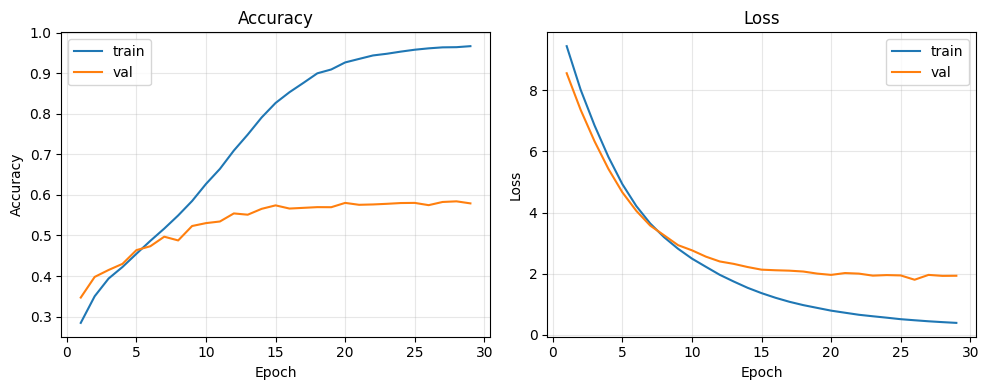

In [8]:
import matplotlib.pyplot as plt

# pull safely (works with both new and old key names)
acc      = history.history.get("accuracy", history.history.get("acc"))
val_acc  = history.history.get("val_accuracy", history.history.get("val_acc"))
loss     = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc, label="train")
plt.plot(epochs, val_acc, label="val")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="val")
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# prediction with the best model
final_cnn = keras.saving.load_model("models/convnet.keras")
final_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    37,749,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,436,887 (436.54 MB)

 Trainable params: 38,145,415 (145.51 MB)

 Non-trainable params: 640 (2.50 KB)

 Optimizer params: 76,290,832 (291.03 MB)

In [10]:
from utilities.evaluations.confusion_matrix import plot_confusion_matrix
from utilities.evaluations.math_metrics import calculate_multiclass_metrics
y_pred_raw = final_cnn.predict(X_test)
y_pred = np.argmax(y_pred_raw, axis=1)

2025-10-07 22:22:30.814460: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,48,48]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,48,48]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-07 22:22:30.826348: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,48,48]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,48,48]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

219/225 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

2025-10-07 22:22:32.496188: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[10,32,48,48]{3,2,1,0}, u8[0]{0}) custom-call(f32[10,1,48,48]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-10-07 22:22:32.505660: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[10,64,48,48]{3,2,1,0}, u8[0]{0}) custom-call(f32[10,32,48,48]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [11]:
calculate_multiclass_metrics(y_test, y_pred, num_classes=7)

{0: {'accuracy': 0.7952061361457334,
  'precision': 0.44963369963369965,
  'recall': 0.5125260960334029,
  'f1_score': 0.4790243902439024},
 1: {'accuracy': 0.9829343446314293,
  'precision': 0.8095238095238095,
  'recall': 0.4594594594594595,
  'f1_score': 0.5862068965517242},
 2: {'accuracy': 0.7736940298507463,
  'precision': 0.4129032258064516,
  'recall': 0.4375,
  'f1_score': 0.42484589853010907},
 3: {'accuracy': 0.8280750798722045,
  'precision': 0.7361614071391619,
  'recall': 0.8021420518602029,
  'f1_score': 0.7677367143242514},
 4: {'accuracy': 0.7917143948071783,
  'precision': 0.5622807017543859,
  'recall': 0.5198702351987023,
  'f1_score': 0.540244416350611},
 5: {'accuracy': 0.7671106178320385,
  'precision': 0.4936708860759494,
  'recall': 0.37530072173215717,
  'f1_score': 0.4264236902050114},
 6: {'accuracy': 0.8927879440258343,
  'precision': 0.6815703380588877,
  'recall': 0.7521058965102286,
  'f1_score': 0.7151029748283754}}

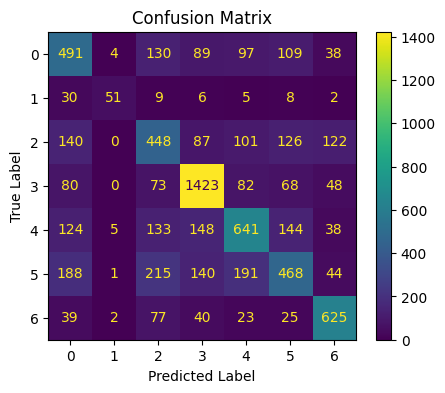

In [12]:
plot_confusion_matrix(y_test, y_pred)